In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv('student-mat-converted.csv')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [42]:
from sklearn.model_selection import train_test_split

# Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate Features (X) and Target (y)
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

# Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes to make sure it worked
print(X_train.shape)
print(X_test.shape)

(316, 41)
(79, 41)


In [43]:
df_encoded

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,2,2,1,2,2,5,5,4,4,...,False,True,False,True,True,False,True,True,False,False
391,17,3,1,2,1,0,2,4,5,3,...,True,False,False,False,False,False,False,True,True,False
392,21,1,1,1,1,3,5,5,3,3,...,False,True,False,False,False,False,False,True,False,False
393,18,3,2,3,1,0,4,4,1,3,...,True,False,False,False,False,False,False,True,True,False


Exploratory Data Analysis


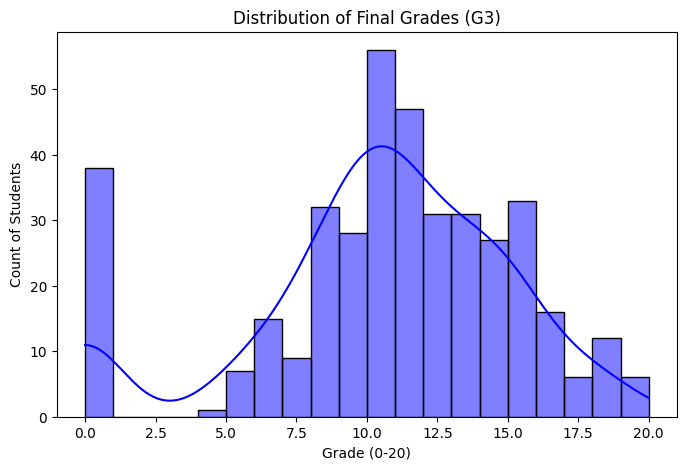

In [44]:
# Univariate Analysis: What does the Target Variable look like?
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], kde=True, bins=20, color='blue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Grade (0-20)')
plt.ylabel('Count of Students')
plt.show()

All Correlations with Final Grade (G3)
G2                   0.904868
G1                   0.801468
Medu                 0.217147
higher_yes           0.182465
Fedu                 0.152457
Mjob_health          0.116158
address_U            0.105756
sex_M                0.103456
paid_yes             0.101996
internet_yes         0.098483
studytime            0.097820
reason_reputation    0.095692
Fjob_teacher         0.095374
famsize_LE3          0.081407
Mjob_services        0.078429
Mjob_teacher         0.057712
Fjob_health          0.057111
reason_other         0.052008
nursery_yes          0.051568
famrel               0.051363
absences             0.034247
guardian_mother      0.022338
activities_yes       0.016100
freetime             0.011307
Fjob_services       -0.016108
reason_home         -0.021359
famsup_yes          -0.039157
school_MS           -0.045017
Walc                -0.051939
Fjob_other          -0.053483
Dalc                -0.054660
Pstatus_T           -0.058009
h

/tmp/ipython-input-1413555333.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_correlations.values, y=all_correlations.index, palette='coolwarm')


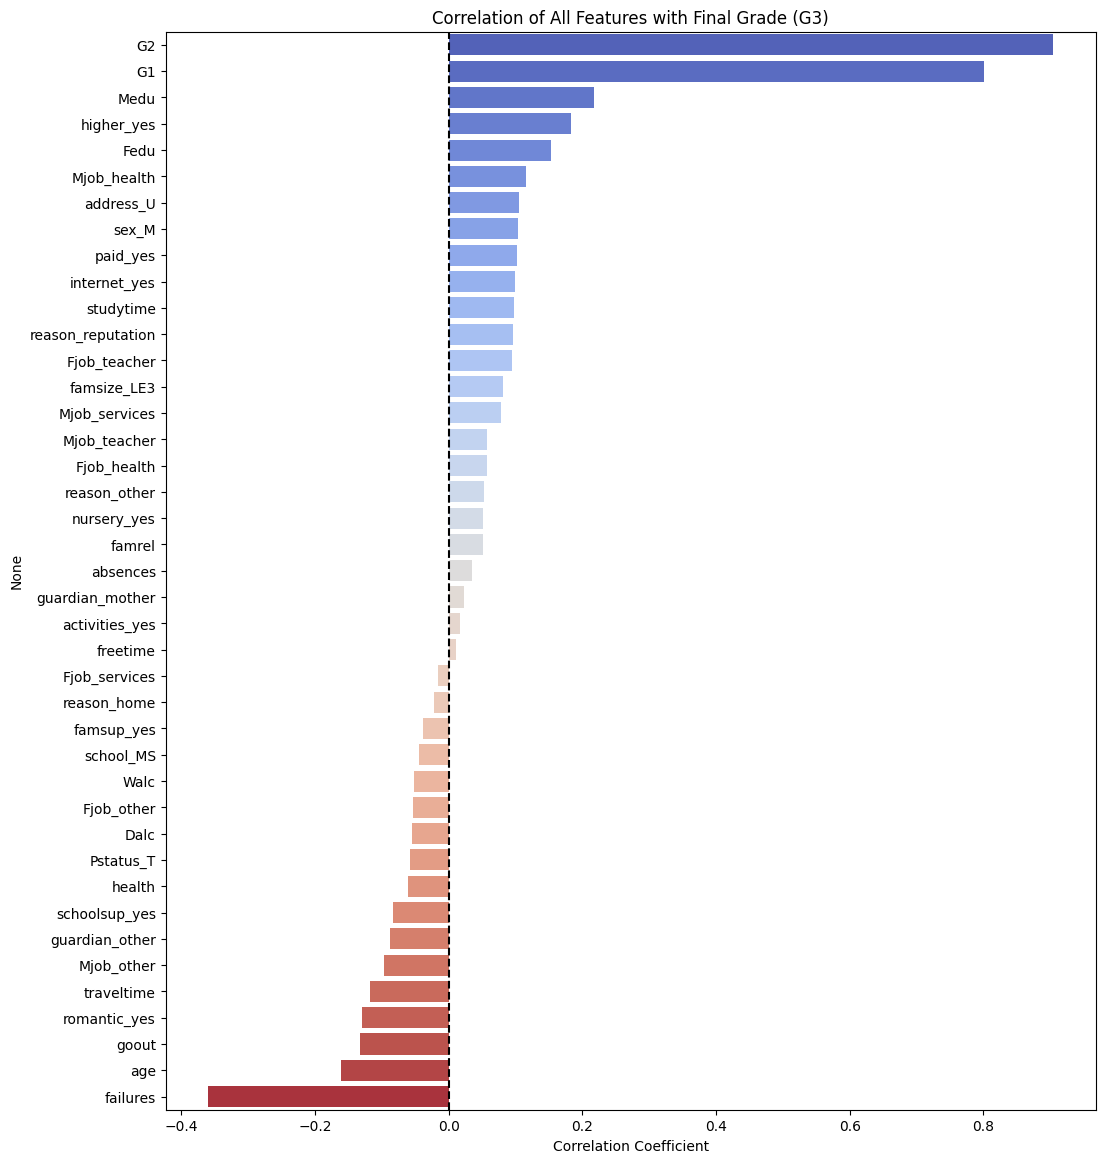

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Correlation for ALL columns
all_correlations = df_encoded.corr()['G3'].sort_values(ascending=False)

# 2. Drop G3 (Target)
all_correlations = all_correlations.drop('G3')

# 3. Print the text list
print("All Correlations with Final Grade (G3)")
print(all_correlations)

# 4. Plot EVERYTHING
plt.figure(figsize=(12, 14))  # Make the figure tall enough to fit all rows
sns.barplot(x=all_correlations.values, y=all_correlations.index, palette='coolwarm')
plt.title('Correlation of All Features with Final Grade (G3)')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

Top 10 Positive Features
G2              0.904868
G1              0.801468
Medu            0.217147
higher_yes      0.182465
Fedu            0.152457
Mjob_health     0.116158
address_U       0.105756
sex_M           0.103456
paid_yes        0.101996
internet_yes    0.098483
Name: G3, dtype: float64

Top 10 Negative Features
Pstatus_T        -0.058009
health           -0.061335
schoolsup_yes    -0.082788
guardian_other   -0.087774
Mjob_other       -0.096477
traveltime       -0.117142
romantic_yes     -0.129970
goout            -0.132791
age              -0.161579
failures         -0.360415
Name: G3, dtype: float64


/tmp/ipython-input-4199683020.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm')


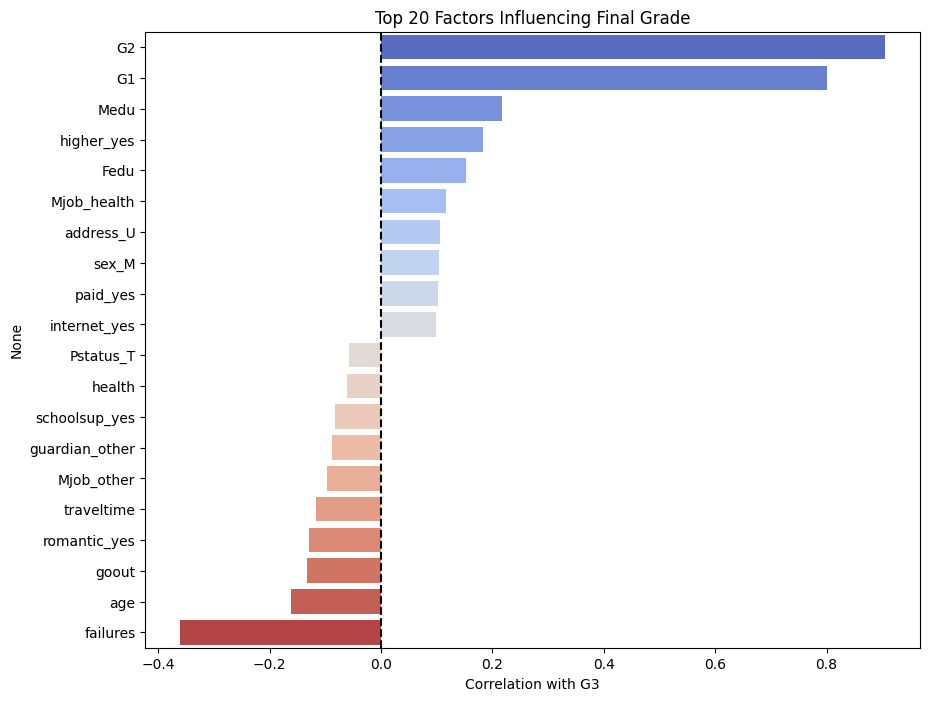

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the correlation of ALL features with G3
all_correlations = df_encoded.corr()['G3'].sort_values(ascending=False)

# 2. Drop G3 (Target)
all_correlations = all_correlations.drop('G3')

# 3. Display the Top 10 Positive and Negative
print("Top 10 Positive Features")
print(all_correlations.head(10))

print("\nTop 10 Negative Features")
print(all_correlations.tail(10))

# 4. Plot them
plt.figure(figsize=(10, 8))
# Combine top 10 positive and top 10 negative for a clean chart
top_features = pd.concat([all_correlations.head(10), all_correlations.tail(10)])
sns.barplot(x=top_features.values, y=top_features.index, palette='coolwarm')
plt.title('Top 20 Factors Influencing Final Grade')
plt.xlabel('Correlation with G3')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

Model Training

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Feature Selection with Lasso
print("1. Lasso to select important features: ")

# Scale the data (Required for Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Lasso
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Identify the Features Lasso kept
coefs = pd.Series(lasso.coef_, index=X_train.columns)
selected_features = coefs[coefs != 0].sort_values(ascending=False)
selected_cols = selected_features.index.tolist()

print(f"Lasso selected {len(selected_cols)} features.")
print(f"Top 3: {selected_cols[:3]}")


# Model Training (Linear Regression)
print("\n2. Linear Regression on selected features: ")

# Train model using ONLY the selected features
lr_selected = LinearRegression()
lr_selected.fit(X_train[selected_cols], y_train)
y_pred_selected = lr_selected.predict(X_test[selected_cols])

# Evaluate
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))
r2_selected = r2_score(y_test, y_pred_selected)

print(f"RMSE: {rmse_selected:.4f}")
print(f"R2 Score: {r2_selected:.4f}")


# Compare with Baseline (G1 & G2 only)
print("\n3. Compare with Baseline (G1 and G2 only): ")

lr_grades = LinearRegression()
lr_grades.fit(X_train[['G1', 'G2']], y_train)
y_pred_grades = lr_grades.predict(X_test[['G1', 'G2']])

rmse_grades = np.sqrt(mean_squared_error(y_test, y_pred_grades))
r2_grades = r2_score(y_test, y_pred_grades)

print(f"RMSE: {rmse_grades:.4f}")
print(f"R2 Score: {r2_grades:.4f}")

# Conclusion
print("\nConclusion:")
if r2_grades > r2_selected:
    print("The simple model (G1 & G2) performed better.")
    print("This shows that past grades are the dominant predictor.")
else:
    print("The complex model (Selected Features) performed better.")

1. Lasso to select important features: 
Lasso selected 18 features.
Top 3: ['G2', 'G1', 'absences']

2. Linear Regression on selected features: 
RMSE: 2.3365
R2 Score: 0.7338

3. Compare with Baseline (G1 and G2 only): 
RMSE: 2.0523
R2 Score: 0.7946

Conclusion:
The simple model (G1 & G2) performed better.
This shows that past grades are the dominant predictor.


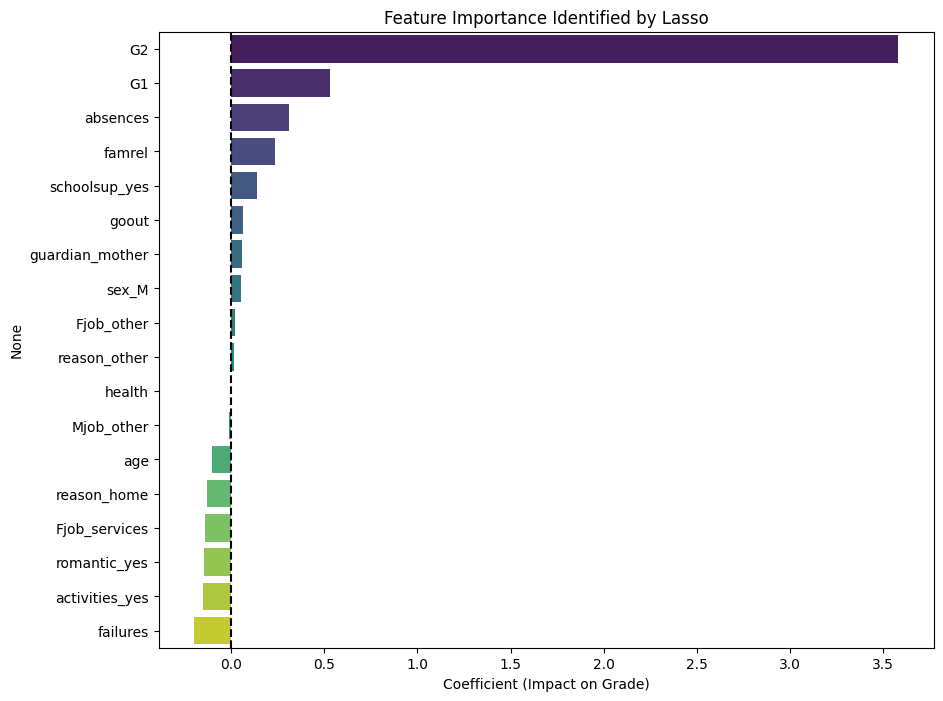

In [48]:
# Get the coefficients from your Lasso model
coefs = pd.Series(lasso.coef_, index=X_train.columns)

# Filter: Keep only non-zero features and sort them
important_features = coefs[coefs != 0].sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x=important_features.values, y=important_features.index, palette='viridis', hue=important_features.index, legend=False)
plt.title('Feature Importance Identified by Lasso')
plt.xlabel('Coefficient (Impact on Grade)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

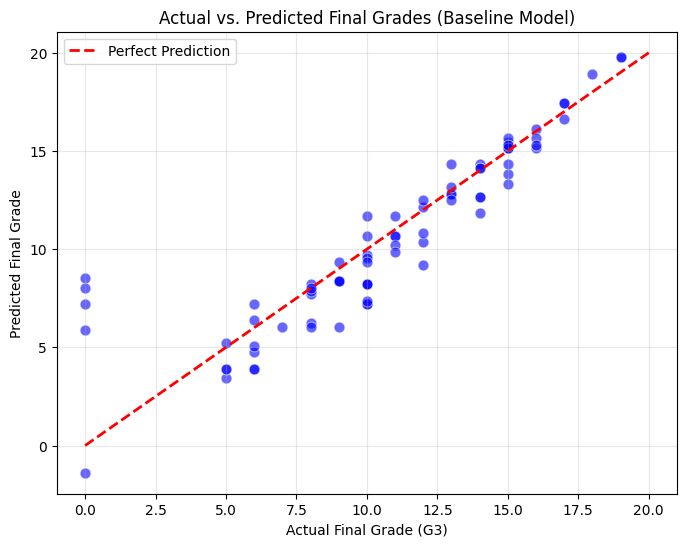

In [49]:
# Train the Baseline Model again
lr_grades = LinearRegression()
lr_grades.fit(X_train[['G1', 'G2']], y_train)
y_pred_grades = lr_grades.predict(X_test[['G1', 'G2']])

# Plot Actual vs. Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_grades, color='blue', alpha=0.6, s=60)

# Add the "Perfect Prediction" line
plt.plot([0, 20], [0, 20], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Final Grades (Baseline Model)')
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Predicted Final Grade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()